# 3. Exploratory Data Analysis

Before training we need to understand the data. Two things matter most:

1. **Class imbalance** - it decides our main evaluation metric (macro-F1)
2. **Text length** - it justifies the maximum token length used for training

All charts are saved to `results/eda/` for the report.

In [1]:
import os
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_from_disk

RAW, OUT = "../data/raw", "../results/eda"
os.makedirs(OUT, exist_ok=True)

sentiment = load_from_disk(os.path.join(RAW, "tweeteval_sentiment"))
emotions = load_from_disk(os.path.join(RAW, "goemotions"))
emotion_names = emotions["train"].features["labels"].feature.names

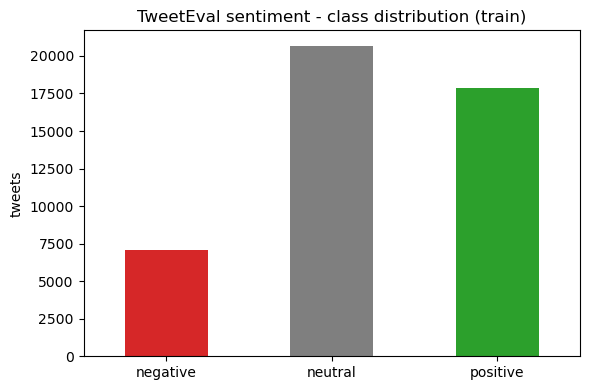

negative     7093
neutral     20673
positive    17849
Name: count, dtype: int64

In [2]:
# --- sentiment class distribution ---
counts = pd.Series(sentiment["train"]["label"]).value_counts().sort_index()
counts.index = ["negative", "neutral", "positive"]

ax = counts.plot(kind="bar", color=["#d62728", "#7f7f7f", "#2ca02c"], figsize=(6, 4))
ax.set_title("TweetEval sentiment - class distribution (train)")
ax.set_ylabel("tweets")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(f"{OUT}/sentiment_class_distribution.png", dpi=150); plt.show()
counts

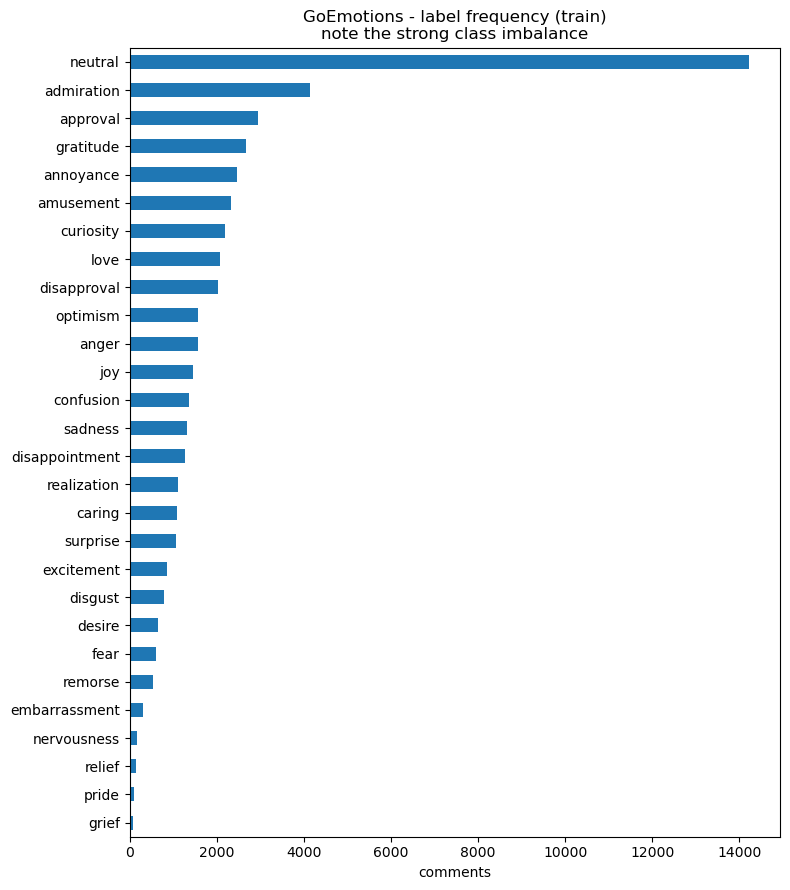

In [3]:
# --- GoEmotions label frequency: heavily imbalanced! ---
counter = Counter()
for labs in emotions["train"]["labels"]:
    counter.update(labs)
emo_counts = pd.Series({emotion_names[i]: c for i, c in counter.items()}).sort_values()

ax = emo_counts.plot(kind="barh", figsize=(8, 9))
ax.set_title("GoEmotions - label frequency (train)\nnote the strong class imbalance")
ax.set_xlabel("comments")
plt.tight_layout(); plt.savefig(f"{OUT}/emotion_label_frequency.png", dpi=150); plt.show()

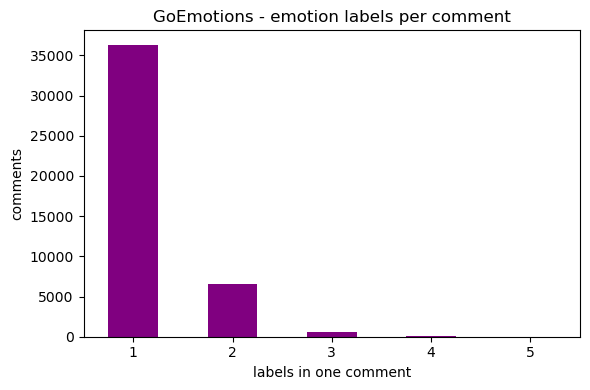

In [4]:
# --- how many emotions can one comment have? (why this task is multi-label) ---
per_comment = pd.Series([len(l) for l in emotions["train"]["labels"]]).value_counts().sort_index()
ax = per_comment.plot(kind="bar", color="purple", figsize=(6, 4))
ax.set_title("GoEmotions - emotion labels per comment")
ax.set_xlabel("labels in one comment"); ax.set_ylabel("comments")
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(f"{OUT}/emotions_per_comment.png", dpi=150); plt.show()

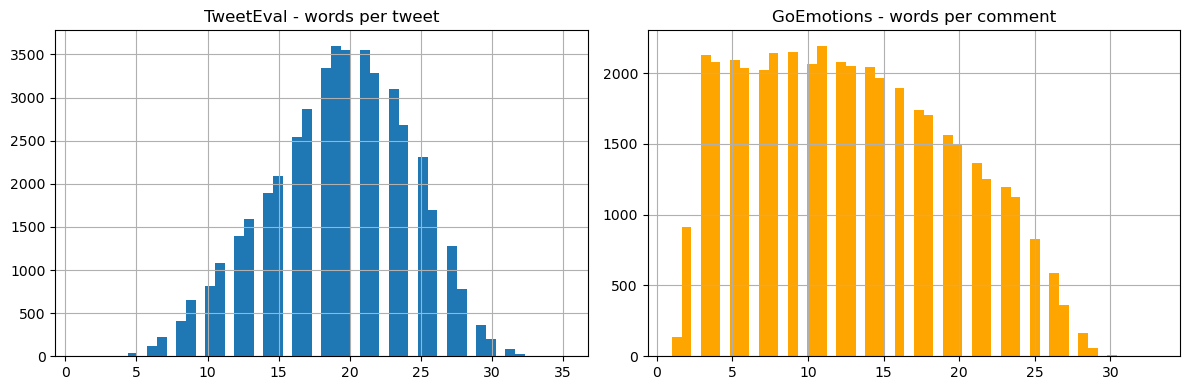

,dataset,median_words,p95_words,max_words
0,TweetEval,20.0,27.0,35
1,GoEmotions,12.0,24.0,33


In [5]:
# --- text lengths: justifies our 64-token maximum ---
sent_len = pd.Series([len(t.split()) for t in sentiment["train"]["text"]])
emo_len = pd.Series([len(t.split()) for t in emotions["train"]["text"]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sent_len.hist(bins=50, ax=axes[0]); axes[0].set_title("TweetEval - words per tweet")
emo_len.hist(bins=50, ax=axes[1], color="orange"); axes[1].set_title("GoEmotions - words per comment")
plt.tight_layout(); plt.savefig(f"{OUT}/text_length_histograms.png", dpi=150); plt.show()

summary = pd.DataFrame({
    "dataset": ["TweetEval", "GoEmotions"],
    "median_words": [sent_len.median(), emo_len.median()],
    "p95_words": [sent_len.quantile(0.95), emo_len.quantile(0.95)],
    "max_words": [sent_len.max(), emo_len.max()]})
summary.to_csv(f"{OUT}/text_length_summary.csv", index=False)
summary